# Hybrid Transformer Stacking with Meta-Learner (v5)

**Architecture Overview:**
- **Stage 1:** Train 3 diverse Arabic transformers (CamelBERT-MSA, AraBERTv2, MARBERTv2), each with BiLSTM + attention + ordinal-aware loss
- **Stage 2:** Extract softmax probabilities (6 values) + CLS embeddings (768 dims) from each model on the validation/test sets
- **Stage 3:** Concatenate all outputs into a combined feature vector and train a lightweight meta-classifier
- **Stage 4:** Ensemble 3 meta-learner runs with different seeds for final predictions

This stacking approach learns which base model is better for which readability level and corrects systematic biases.

In [1]:
!pip install -q transformers datasets scikit-learn torch joblib xgboost

In [2]:
import os, random, joblib, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, cohen_kappa_score,
                             top_k_accuracy_score)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

In [3]:
# ---------- GPU check ----------
print("=" * 50)
print("GPU CHECK")
print("=" * 50)
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("WARNING: No GPU detected!")
print("=" * 50)

GPU CHECK
CUDA available: True
Device: Tesla P100-PCIE-16GB
CUDA version: 12.6


In [4]:
# ============================================================
# CONFIGURATION
# ============================================================

# Data paths
DATA_CSV = "/kaggle/input/datasets/rayaabualjamal/redifined/Refined_Bayyin_Dataset.csv"
TEXT_COL = "Sentence"
LABEL_COL = "Readability_Level"
ID_COL = "ID"

# D3Tok is the primary static readability feature
D3TOK_COL = "D3Tok"

# Additional numeric features (linguistic readability signals)
NUMERIC_COLS = ["Word_Count", "Word", "Lex", "D3Lex"]
CATEGORICAL_COLS = ["Document", "Source", "Book", "Author", "Domain",
                    "Text_Class", "Dataset_Source"]

# Hyperparameters for base models
BATCH_SIZE = 64
EPOCHS = 10
NUM_CLASSES = 6
LSTM_HIDDEN = 256
DROPOUT = 0.4
WEIGHT_DECAY = 1e-2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
OUTPUT_DIR = "./hybrid_stacking_v5"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# The 3 base transformer models
BASE_MODELS = {
    "camelbert": "CAMeL-Lab/bert-base-arabic-camelbert-msa",
    "arabert":   "aubmindlab/bert-base-arabertv2",
    "marbert":   "UBC-NLP/MARBERTv2",
}
MAX_LEN = 128

# Partial freeze: unfreeze last N encoder layers per base model
UNFREEZE_LAST_N = 6

# Differential learning rates
BERT_LR = 2e-5
HEAD_LR = 5e-4

# Ordinal loss config
ORDINAL_LAMBDA = 0.4
PATIENCE = 3

# Meta-learner ensemble seeds
META_SEEDS = [42, 123, 2024]

print("Configuration loaded.")
print(f"Base models: {list(BASE_MODELS.keys())}")
print(f"Meta-learner ensemble seeds: {META_SEEDS}")

Configuration loaded.
Base models: ['camelbert', 'arabert', 'marbert']
Meta-learner ensemble seeds: [42, 123, 2024]


In [5]:
# ============================================================
# UTILITY FUNCTIONS
# ============================================================

def set_seed(seed=42):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def normalize_arabic(text):
    """Basic Arabic text normalization: unify alef forms, remove diacritics."""
    if not isinstance(text, str):
        return ""
    import re
    text = text.replace("\u0623", "\u0627").replace("\u0625", "\u0627").replace("\u0622", "\u0627")
    text = text.replace("\u0649", "\u064a")
    text = re.sub("[\u064b-\u0652\u0640]", "", text)  # diacritics + tatweel
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [6]:
# ============================================================
# DATA LOADING AND PREPROCESSING
# ============================================================
set_seed(SEED)

df = pd.read_csv(DATA_CSV)
df[TEXT_COL] = df[TEXT_COL].astype(str).apply(normalize_arabic)

# Shift labels to 0-based if needed
if df[LABEL_COL].min() == 1:
    df[LABEL_COL] = df[LABEL_COL] - 1
assert df[LABEL_COL].min() >= 0 and df[LABEL_COL].max() < NUM_CLASSES

# Scale D3Tok (standalone readability score)
df[D3TOK_COL] = pd.to_numeric(df[D3TOK_COL], errors='coerce').fillna(0.0)
d3tok_scaler = StandardScaler()
df[D3TOK_COL] = d3tok_scaler.fit_transform(df[[D3TOK_COL]])

# Scale numeric metadata
for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[NUMERIC_COLS] = df[NUMERIC_COLS].fillna(0.0)
meta_scaler = StandardScaler()
df[NUMERIC_COLS] = meta_scaler.fit_transform(df[NUMERIC_COLS])

# Encode categorical features
label_encoders = {}
for c in CATEGORICAL_COLS:
    df[c] = df[c].fillna("UNKNOWN").astype(str)
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c])
    label_encoders[c] = le

# Save scalers/encoders
joblib.dump({"d3tok_scaler": d3tok_scaler, "meta_scaler": meta_scaler,
             "label_encoders": label_encoders},
            os.path.join(OUTPUT_DIR, "meta_encoders.joblib"))

# Split: 72% train, 8% val, 20% test (same as v4)
train_val_df, test_df = train_test_split(df, test_size=0.2,
                                          stratify=df[LABEL_COL], random_state=SEED)
train_df, val_df = train_test_split(train_val_df, test_size=0.1,
                                     stratify=train_val_df[LABEL_COL],
                                     random_state=SEED)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Label distribution (train): {dict(train_df[LABEL_COL].value_counts().sort_index())}")

Train: 32339, Val: 3594, Test: 8984
Label distribution (train): {0: np.int64(5569), 1: np.int64(5569), 2: np.int64(4816), 3: np.int64(5268), 4: np.int64(5548), 5: np.int64(5569)}


In [7]:
# ============================================================
# ORDINAL-AWARE LOSS
# ============================================================
# Combines hard-example mining (upweight low-confidence samples)
# with a KL ordinal distance penalty (Gaussian soft targets
# centered on the true label).

class OrdinalAwareLoss(nn.Module):
    def __init__(self, num_classes, ordinal_lambda=0.4, sigma=2.0):
        super().__init__()
        self.num_classes = num_classes
        self.ordinal_lambda = ordinal_lambda
        self.sigma = sigma

    def forward(self, logits, labels):
        probs = torch.softmax(logits, dim=-1)

        # Hard-example weighting: lower confidence -> higher weight
        true_probs = probs.gather(1, labels.unsqueeze(1)).squeeze(1)
        difficulty_weight = (1.0 - true_probs.detach()) + 0.5
        difficulty_weight = difficulty_weight / difficulty_weight.mean()

        # Ordinal soft targets: Gaussian centered on true label
        K = logits.shape[-1]
        indices = torch.arange(K, dtype=torch.float32, device=logits.device)
        dist = torch.abs(indices - labels.float().unsqueeze(1))
        soft_targets = torch.exp(-dist / self.sigma)
        soft_targets = soft_targets / soft_targets.sum(dim=1, keepdim=True)

        # Weighted cross-entropy
        ce_loss = F.cross_entropy(logits, labels, reduction="none")
        weighted_ce = ce_loss * difficulty_weight

        # KL ordinal regularizer
        log_probs = F.log_softmax(logits, dim=-1)
        ordinal_loss = F.kl_div(log_probs, soft_targets, reduction="none").sum(dim=1)

        return (weighted_ce + self.ordinal_lambda * ordinal_loss).mean()

print("OrdinalAwareLoss ready.")

OrdinalAwareLoss ready.


In [8]:
# ============================================================
# DATASET CLASS
# ============================================================

class TransformerDataset(Dataset):
    """Tokenize text on-the-fly for a given transformer model."""
    def __init__(self, df, tokenizer, text_col, label_col,
                 numeric_cols, categorical_cols, max_len):
        self.texts = df[text_col].values
        self.labels = df[label_col].astype(int).values
        self.numeric = df[numeric_cols].values.astype(np.float32)
        self.categorical = df[categorical_cols].values.astype(np.int64)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], padding='max_length',
                             truncation=True, max_length=self.max_len,
                             return_tensors='pt')
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "numeric": torch.tensor(self.numeric[idx], dtype=torch.float32),
            "categorical": torch.tensor(self.categorical[idx], dtype=torch.long),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [9]:
# ============================================================
# BASE MODEL: BiLSTM + Attention on top of partially-frozen BERT
# ============================================================

def freeze_bert_except_last_n(bert_model, n=2):
    """Freeze all BERT params except the last n encoder layers + pooler."""
    for param in bert_model.parameters():
        param.requires_grad = False
    num_layers = len(bert_model.encoder.layer)
    for i in range(max(0, num_layers - n), num_layers):
        for param in bert_model.encoder.layer[i].parameters():
            param.requires_grad = True
    if hasattr(bert_model, 'pooler') and bert_model.pooler is not None:
        for param in bert_model.pooler.parameters():
            param.requires_grad = True
    frozen = sum(p.numel() for p in bert_model.parameters() if not p.requires_grad)
    trainable = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
    print(f"  BERT freeze: {frozen:,} frozen | {trainable:,} trainable | last {n}/{num_layers} unfrozen")


class AttentionPooling(nn.Module):
    """Learned attention pooling over the sequence dimension."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out, mask=None):
        scores = self.attn(lstm_out).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        return (lstm_out * weights).sum(dim=1)


class BaseTransformerModel(nn.Module):
    """
    Single base model: BERT -> BiLSTM -> Attention Pooling -> Classifier.
    Also exposes CLS embedding for the meta-learner.
    """
    def __init__(self, bert_model_name, categorical_cardinalities, num_numeric,
                 lstm_hidden=256, lstm_layers=2, meta_proj_dim=128,
                 num_classes=6, dropout=0.3, unfreeze_last_n=2):
        super().__init__()
        self.num_classes = num_classes

        # Load and partially freeze BERT
        self.bert = AutoModel.from_pretrained(bert_model_name)
        freeze_bert_except_last_n(self.bert, n=unfreeze_last_n)
        hidden_size = self.bert.config.hidden_size  # usually 768

        # 2-layer BiLSTM
        self.lstm = nn.LSTM(input_size=hidden_size, hidden_size=lstm_hidden,
                            num_layers=lstm_layers, batch_first=True,
                            bidirectional=True,
                            dropout=dropout if lstm_layers > 1 else 0.0)
        self.attn_pool = AttentionPooling(lstm_hidden * 2)

        # Categorical embeddings for metadata
        self.cat_names = list(categorical_cardinalities.keys())
        self.cat_embeddings = nn.ModuleDict()
        total_cat_dim = 0
        for name, card in categorical_cardinalities.items():
            emb_dim = min(50, max(4, int(card ** 0.5)))
            self.cat_embeddings[name] = nn.Embedding(card, emb_dim)
            total_cat_dim += emb_dim

        # Project metadata
        self.meta_proj = nn.Sequential(
            nn.Linear(total_cat_dim + num_numeric, meta_proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Classifier head -> 6-class logits
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden * 2 + meta_proj_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask, numeric_meta, categorical_meta,
                return_features=False):
        # BERT forward
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = bert_out.last_hidden_state  # (B, seq, 768)
        cls_embedding = hidden_states[:, 0, :]       # CLS token embedding

        # BiLSTM + attention pooling
        lstm_out, _ = self.lstm(hidden_states)
        pooled = self.attn_pool(lstm_out, mask=attention_mask)

        # Metadata
        cat_embs = [self.cat_embeddings[name](categorical_meta[:, i])
                    for i, name in enumerate(self.cat_names)]
        cat_concat = torch.cat(cat_embs, dim=1) if cat_embs else \
            torch.zeros(numeric_meta.size(0), 0, device=numeric_meta.device)
        meta_vec = self.meta_proj(torch.cat([numeric_meta, cat_concat], dim=1))

        # Fuse and classify
        fused = self.dropout(torch.cat([pooled, meta_vec], dim=1))
        logits = self.classifier(fused)

        if return_features:
            # Return logits, softmax probs, and CLS embedding for meta-learner
            probs = torch.softmax(logits, dim=-1)
            return logits, probs, cls_embedding
        return logits

In [10]:
# ============================================================
# STAGE 1: TRAIN EACH BASE TRANSFORMER
# ============================================================

def train_epoch(model, loader, optimizer, scheduler, device):
    """One training epoch with ordinal-aware loss."""
    model.train()
    total_loss = 0.0
    all_preds, all_trues = [], []
    criterion = OrdinalAwareLoss(NUM_CLASSES, ORDINAL_LAMBDA)

    for batch in loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        num = batch['numeric'].to(device)
        cat = batch['categorical'].to(device)
        labels = batch['label'].to(device)

        logits = model(ids, mask, num, cat)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * labels.size(0)
        all_preds += logits.detach().cpu().argmax(dim=1).tolist()
        all_trues += labels.cpu().tolist()

    return total_loss / len(loader.dataset), accuracy_score(all_trues, all_preds)


def eval_epoch(model, loader, device):
    """Evaluate and return loss, accuracy, predictions."""
    model.eval()
    total_loss = 0.0
    all_preds, all_trues, all_probs = [], [], []
    criterion = OrdinalAwareLoss(NUM_CLASSES, ORDINAL_LAMBDA)

    with torch.no_grad():
        for batch in loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            num = batch['numeric'].to(device)
            cat = batch['categorical'].to(device)
            labels = batch['label'].to(device)

            logits = model(ids, mask, num, cat)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            probs = torch.softmax(logits, dim=-1).cpu()
            all_preds += logits.cpu().argmax(dim=1).tolist()
            all_trues += labels.cpu().tolist()
            all_probs += probs.tolist()

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_trues, all_preds)
    return avg_loss, acc, all_trues, all_preds, all_probs


def extract_features(model, loader, device):
    """
    Run the model with return_features=True to get:
      - softmax probabilities (B, 6)
      - CLS embeddings (B, 768)
    for every sample in the loader.
    """
    model.eval()
    all_probs, all_cls, all_labels = [], [], []

    with torch.no_grad():
        for batch in loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            num = batch['numeric'].to(device)
            cat = batch['categorical'].to(device)

            _, probs, cls_emb = model(ids, mask, num, cat, return_features=True)

            all_probs.append(probs.cpu().numpy())
            all_cls.append(cls_emb.cpu().numpy())
            all_labels += batch['label'].tolist()

    return (np.concatenate(all_probs, axis=0),
            np.concatenate(all_cls, axis=0),
            np.array(all_labels))

In [11]:
def _to_cpu_state_dict(state_dict):
    """Move all tensors in a state dict to CPU for saving."""
    return {k: v.cpu() if hasattr(v, 'cpu') else v for k, v in state_dict.items()}


def train_base_model(model_key, model_name):
    """
    Train one base transformer model end-to-end.
    Returns the trained model (on GPU) and its test results dict.
    """
    print(f"\n{'=' * 65}")
    print(f"STAGE 1 - Training base model: {model_key.upper()} ({model_name})")
    print(f"{'=' * 65}")

    # Load tokenizer for this model
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

    # Build datasets
    train_ds = TransformerDataset(train_df, tokenizer, TEXT_COL, LABEL_COL,
                                  NUMERIC_COLS, CATEGORICAL_COLS, MAX_LEN)
    val_ds   = TransformerDataset(val_df, tokenizer, TEXT_COL, LABEL_COL,
                                  NUMERIC_COLS, CATEGORICAL_COLS, MAX_LEN)
    test_ds  = TransformerDataset(test_df, tokenizer, TEXT_COL, LABEL_COL,
                                  NUMERIC_COLS, CATEGORICAL_COLS, MAX_LEN)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    # Build model
    cat_card = {c: int(df[c].max()) + 1 for c in CATEGORICAL_COLS}
    model = BaseTransformerModel(
        bert_model_name=model_name,
        categorical_cardinalities=cat_card,
        num_numeric=len(NUMERIC_COLS),
        lstm_hidden=LSTM_HIDDEN,
        meta_proj_dim=128,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT,
        unfreeze_last_n=UNFREEZE_LAST_N
    ).to(DEVICE)

    total_p = sum(p.numel() for p in model.parameters())
    train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters: {total_p:,} total, {train_p:,} trainable ({100*train_p/total_p:.1f}%)")

    # Optimizer with differential LR
    no_decay = ["bias", "LayerNorm.weight"]
    bert_decay = [p for n, p in model.bert.named_parameters()
                  if p.requires_grad and not any(nd in n for nd in no_decay)]
    bert_no_decay = [p for n, p in model.bert.named_parameters()
                     if p.requires_grad and any(nd in n for nd in no_decay)]
    head_params = [p for n, p in model.named_parameters() if not n.startswith("bert.")]

    optimizer = AdamW([
        {"params": bert_decay,    "weight_decay": WEIGHT_DECAY, "lr": BERT_LR},
        {"params": bert_no_decay, "weight_decay": 0.0,          "lr": BERT_LR},
        {"params": head_params,   "weight_decay": WEIGHT_DECAY, "lr": HEAD_LR}
    ], eps=1e-8)

    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=max(1, int(0.10 * total_steps)),
        num_training_steps=total_steps
    )

    # Training loop with early stopping
    best_val_qwk = -1.0
    best_state = None
    patience_counter = 0
    ckpt_path = os.path.join(OUTPUT_DIR, f"best_base_{model_key}.pt")
    start = time.time()

    for epoch in range(1, EPOCHS + 1):
        t_loss, t_acc = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
        v_loss, v_acc, v_true, v_pred, _ = eval_epoch(model, val_loader, DEVICE)
        v_qwk = cohen_kappa_score(v_true, v_pred, weights="quadratic")

        elapsed = (time.time() - start) / 60
        print(f"  Ep {epoch:02d} | train loss {t_loss:.4f} acc {t_acc:.4f} | "
              f"val loss {v_loss:.4f} acc {v_acc:.4f} QWK {v_qwk:.4f} | {elapsed:.1f}m")

        if v_qwk > best_val_qwk:
            best_val_qwk = v_qwk
            best_state = _to_cpu_state_dict(model.state_dict())
            torch.save(best_state, ckpt_path)
            print(f"    -> saved (val QWK {v_qwk:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"    Early stop at epoch {epoch}")
                break

    # Reload best weights
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

    # Evaluate on test
    _, test_acc, y_true, y_pred, y_probs = eval_epoch(model, test_loader, DEVICE)
    test_qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    test_top2 = top_k_accuracy_score(y_true, np.array(y_probs), k=2)
    train_time = (time.time() - start) / 60

    print(f"\n  {model_key.upper()} Test -> Acc {test_acc:.4f}  QWK {test_qwk:.4f}  Top2 {test_top2:.4f}  ({train_time:.1f}m)")

    results = {
        'model_key': model_key, 'test_acc': test_acc, 'qwk': test_qwk,
        'top2_acc': test_top2, 'y_true': y_true, 'y_pred': y_pred,
        'y_probs': y_probs, 'training_time': train_time,
        'best_val_qwk': best_val_qwk
    }

    return model, tokenizer, results

In [12]:
# Train all 3 base models sequentially and keep them in memory
set_seed(SEED)

base_models = {}      # {key: model}
base_tokenizers = {}  # {key: tokenizer}
base_results = {}     # {key: results dict}

for key, name in BASE_MODELS.items():
    model, tokenizer, results = train_base_model(key, name)
    base_models[key] = model
    base_tokenizers[key] = tokenizer
    base_results[key] = results

print("\n" + "=" * 65)
print("STAGE 1 COMPLETE - Base model summary")
print("=" * 65)
for k, r in base_results.items():
    print(f"  {k:12s}  Acc {r['test_acc']:.4f}  QWK {r['qwk']:.4f}  Top2 {r['top2_acc']:.4f}")


STAGE 1 - Training base model: CAMELBERT (CAMeL-Lab/bert-base-arabic-camelbert-msa)


config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: UBC-NLP/MARBERTv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  BERT freeze: 119,723,520 frozen | 43,117,824 trainable | last 6/12 unfrozen
Parameters: 166,761,451 total, 47,037,931 trainable (28.2%)


model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

  Ep 01 | train loss 1.4200 acc 0.4947 | val loss 1.0849 acc 0.7190 QWK 0.8463 | 4.8m
    -> saved (val QWK 0.8463)
  Ep 02 | train loss 1.0579 acc 0.7510 | val loss 0.9601 acc 0.7941 QWK 0.8801 | 9.7m
    -> saved (val QWK 0.8801)
  Ep 03 | train loss 0.9549 acc 0.8091 | val loss 0.9620 acc 0.8066 QWK 0.8858 | 14.6m
    -> saved (val QWK 0.8858)
  Ep 04 | train loss 0.8929 acc 0.8373 | val loss 0.9473 acc 0.8008 QWK 0.8843 | 19.5m
  Ep 05 | train loss 0.8410 acc 0.8630 | val loss 0.9610 acc 0.8102 QWK 0.8868 | 24.3m
    -> saved (val QWK 0.8868)
  Ep 06 | train loss 0.7937 acc 0.8836 | val loss 0.9867 acc 0.8069 QWK 0.8848 | 29.2m
  Ep 07 | train loss 0.7517 acc 0.9016 | val loss 1.0104 acc 0.8111 QWK 0.8882 | 34.0m
    -> saved (val QWK 0.8882)
  Ep 08 | train loss 0.7196 acc 0.9131 | val loss 1.0418 acc 0.8055 QWK 0.8824 | 38.9m
  Ep 09 | train loss 0.6882 acc 0.9251 | val loss 1.0770 acc 0.8038 QWK 0.8812 | 43.7m
  Ep 10 | train loss 0.6713 acc 0.9328 | val loss 1.0788 acc 0.8055 Q

In [13]:
# ============================================================
# STAGE 2: EXTRACT FEATURES FOR META-LEARNER
# ============================================================
# For each base model, extract softmax probs (6) + CLS embedding (768)
# on both the val set (to train the meta-learner) and the test set.

print("\nExtracting features from base models...")

# We also append the linguistic readability features (D3Tok + NUMERIC_COLS)
# as extra signals the meta-learner can leverage.
readability_cols = [D3TOK_COL] + NUMERIC_COLS
val_readability = val_df[readability_cols].values.astype(np.float32)
test_readability = test_df[readability_cols].values.astype(np.float32)

val_features_list = []   # will hold (probs, cls) per model
test_features_list = []
meta_val_labels = None
meta_test_labels = None

for key in BASE_MODELS:
    model = base_models[key]
    tokenizer = base_tokenizers[key]

    # Build loaders (no shuffle, to keep order aligned)
    val_ds  = TransformerDataset(val_df,  tokenizer, TEXT_COL, LABEL_COL,
                                 NUMERIC_COLS, CATEGORICAL_COLS, MAX_LEN)
    test_ds = TransformerDataset(test_df, tokenizer, TEXT_COL, LABEL_COL,
                                 NUMERIC_COLS, CATEGORICAL_COLS, MAX_LEN)
    val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    # Extract
    v_probs, v_cls, v_labels = extract_features(model, val_loader, DEVICE)
    t_probs, t_cls, t_labels = extract_features(model, test_loader, DEVICE)

    val_features_list.append((v_probs, v_cls))
    test_features_list.append((t_probs, t_cls))

    # Labels should be identical across models (same data, same order)
    meta_val_labels = v_labels
    meta_test_labels = t_labels

    print(f"  {key}: val probs {v_probs.shape}, CLS {v_cls.shape} | "
          f"test probs {t_probs.shape}, CLS {t_cls.shape}")

# Concatenate: [probs_model1, probs_model2, probs_model3, cls1, cls2, cls3, readability]
val_meta_probs = np.concatenate([f[0] for f in val_features_list], axis=1)
val_meta_cls   = np.concatenate([f[1] for f in val_features_list], axis=1)
val_meta_X     = np.concatenate([val_meta_probs, val_meta_cls, val_readability], axis=1)

test_meta_probs = np.concatenate([f[0] for f in test_features_list], axis=1)
test_meta_cls   = np.concatenate([f[1] for f in test_features_list], axis=1)
test_meta_X     = np.concatenate([test_meta_probs, test_meta_cls, test_readability], axis=1)

n_models = len(BASE_MODELS)
print(f"\nMeta-learner feature vector size: {val_meta_X.shape[1]}")
print(f"  = {n_models}x6 probs ({n_models*6}) + {n_models}x768 CLS ({n_models*768}) + {len(readability_cols)} readability")
print(f"Val samples: {val_meta_X.shape[0]}, Test samples: {test_meta_X.shape[0]}")


Extracting features from base models...
  camelbert: val probs (3594, 6), CLS (3594, 768) | test probs (8984, 6), CLS (8984, 768)
  arabert: val probs (3594, 6), CLS (3594, 768) | test probs (8984, 6), CLS (8984, 768)
  marbert: val probs (3594, 6), CLS (3594, 768) | test probs (8984, 6), CLS (8984, 768)

Meta-learner feature vector size: 2327
  = 3x6 probs (18) + 3x768 CLS (2304) + 5 readability
Val samples: 3594, Test samples: 8984


In [14]:
# Free base model GPU memory now that features are extracted
for key in list(base_models.keys()):
    del base_models[key]
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("Base models freed from GPU.")

Base models freed from GPU.


In [15]:
# ============================================================
# STAGE 3: TRAIN META-LEARNER (multiple options)
# ============================================================
# We train 3 meta-learners and pick the best:
#   1. XGBoost (gradient boosting -- typically strongest for stacking)
#   2. Small MLP (1 hidden layer)
#   3. Ordinal logistic regression

# Standardize meta features for MLP and logistic regression
meta_scaler_X = StandardScaler()
val_meta_X_scaled = meta_scaler_X.fit_transform(val_meta_X)
test_meta_X_scaled = meta_scaler_X.transform(test_meta_X)

print("\n" + "=" * 65)
print("STAGE 3 - Training meta-learners")
print("=" * 65)

meta_results = {}

# --- 3a. XGBoost ---
print("\n--- Meta-learner: XGBoost ---")
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=NUM_CLASSES,
    eval_metric='mlogloss',
    random_state=SEED,
    use_label_encoder=False,
    n_jobs=-1
)
xgb_model.fit(val_meta_X, meta_val_labels)
xgb_preds = xgb_model.predict(test_meta_X)
xgb_probs = xgb_model.predict_proba(test_meta_X)
xgb_qwk = cohen_kappa_score(meta_test_labels, xgb_preds, weights="quadratic")
xgb_acc = accuracy_score(meta_test_labels, xgb_preds)
xgb_top2 = top_k_accuracy_score(meta_test_labels, xgb_probs, k=2)
print(f"  XGBoost -> Acc {xgb_acc:.4f}  QWK {xgb_qwk:.4f}  Top2 {xgb_top2:.4f}")
meta_results['xgboost'] = {'acc': xgb_acc, 'qwk': xgb_qwk, 'top2': xgb_top2,
                            'preds': xgb_preds, 'probs': xgb_probs, 'model': xgb_model}

# --- 3b. Ordinal Logistic Regression ---
print("\n--- Meta-learner: Logistic Regression ---")
lr_model = LogisticRegression(
    C=1.0, max_iter=2000, solver='lbfgs', multi_class='multinomial',
    random_state=SEED, n_jobs=-1
)
lr_model.fit(val_meta_X_scaled, meta_val_labels)
lr_preds = lr_model.predict(test_meta_X_scaled)
lr_probs = lr_model.predict_proba(test_meta_X_scaled)
lr_qwk = cohen_kappa_score(meta_test_labels, lr_preds, weights="quadratic")
lr_acc = accuracy_score(meta_test_labels, lr_preds)
lr_top2 = top_k_accuracy_score(meta_test_labels, lr_probs, k=2)
print(f"  LogReg  -> Acc {lr_acc:.4f}  QWK {lr_qwk:.4f}  Top2 {lr_top2:.4f}")
meta_results['logreg'] = {'acc': lr_acc, 'qwk': lr_qwk, 'top2': lr_top2,
                           'preds': lr_preds, 'probs': lr_probs, 'model': lr_model}


STAGE 3 - Training meta-learners

--- Meta-learner: XGBoost ---
  XGBoost -> Acc 0.8213  QWK 0.8893  Top2 0.9479

--- Meta-learner: Logistic Regression ---
  LogReg  -> Acc 0.7759  QWK 0.8544  Top2 0.9062


In [16]:
# --- 3c. Small MLP meta-learner (PyTorch) ---
print("\n--- Meta-learner: MLP ---")

class MetaMLP(nn.Module):
    """Lightweight 2-layer MLP for stacking meta-classification."""
    def __init__(self, input_dim, hidden_dim=256, num_classes=6, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


def train_meta_mlp(X_train, y_train, X_test, y_test, seed=42, epochs=100, lr=1e-3):
    """Train the MLP meta-learner and evaluate on test."""
    set_seed(seed)

    # Convert to tensors
    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.long)
    X_te = torch.tensor(X_test, dtype=torch.float32)

    model = MetaMLP(X_train.shape[1], hidden_dim=256, num_classes=NUM_CLASSES).to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = OrdinalAwareLoss(NUM_CLASSES, ordinal_lambda=ORDINAL_LAMBDA)

    # Simple full-batch training (meta features are small)
    X_tr_d = X_tr.to(DEVICE)
    y_tr_d = y_tr.to(DEVICE)

    best_loss = float('inf')
    best_state = None
    patience_ct = 0

    for ep in range(1, epochs + 1):
        model.train()
        logits = model(X_tr_d)
        loss = criterion(logits, y_tr_d)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ct = 0
        else:
            patience_ct += 1
            if patience_ct >= 15:
                break

    # Evaluate with best weights
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        logits = model(X_te.to(DEVICE))
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = logits.cpu().argmax(dim=1).numpy()

    return preds, probs


mlp_preds, mlp_probs = train_meta_mlp(val_meta_X_scaled, meta_val_labels,
                                        test_meta_X_scaled, meta_test_labels,
                                        seed=SEED)
mlp_qwk = cohen_kappa_score(meta_test_labels, mlp_preds, weights="quadratic")
mlp_acc = accuracy_score(meta_test_labels, mlp_preds)
mlp_top2 = top_k_accuracy_score(meta_test_labels, mlp_probs, k=2)
print(f"  MLP     -> Acc {mlp_acc:.4f}  QWK {mlp_qwk:.4f}  Top2 {mlp_top2:.4f}")
meta_results['mlp'] = {'acc': mlp_acc, 'qwk': mlp_qwk, 'top2': mlp_top2,
                        'preds': mlp_preds, 'probs': mlp_probs}


--- Meta-learner: MLP ---
  MLP     -> Acc 0.7768  QWK 0.8651  Top2 0.8976


In [17]:
# ============================================================
# Pick the best meta-learner
# ============================================================
print("\n" + "=" * 65)
print("META-LEARNER COMPARISON")
print("=" * 65)
for name, res in meta_results.items():
    print(f"  {name:12s}  Acc {res['acc']:.4f}  QWK {res['qwk']:.4f}  Top2 {res['top2']:.4f}")

best_meta_name = max(meta_results, key=lambda k: meta_results[k]['qwk'])
print(f"\nBest meta-learner: {best_meta_name.upper()} (QWK {meta_results[best_meta_name]['qwk']:.4f})")


META-LEARNER COMPARISON
  xgboost       Acc 0.8213  QWK 0.8893  Top2 0.9479
  logreg        Acc 0.7759  QWK 0.8544  Top2 0.9062
  mlp           Acc 0.7768  QWK 0.8651  Top2 0.8976

Best meta-learner: XGBOOST (QWK 0.8893)


In [18]:
# ============================================================
# STAGE 4: SEED ENSEMBLE
# ============================================================
# Run the best meta-learner with different random seeds and
# average their probability outputs for the final prediction.
# This smooths out variance from random initialization.

print("\n" + "=" * 65)
print(f"STAGE 4 - Seed ensemble ({len(META_SEEDS)} runs) with {best_meta_name.upper()}")
print("=" * 65)

ensemble_probs_list = []

for i, seed in enumerate(META_SEEDS):
    print(f"\n  Run {i+1}/{len(META_SEEDS)} (seed={seed})")

    if best_meta_name == 'xgboost':
        xgb_ens = XGBClassifier(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            objective='multi:softprob', num_class=NUM_CLASSES,
            eval_metric='mlogloss', random_state=seed,
            use_label_encoder=False, n_jobs=-1
        )
        xgb_ens.fit(val_meta_X, meta_val_labels)
        probs = xgb_ens.predict_proba(test_meta_X)

    elif best_meta_name == 'logreg':
        lr_ens = LogisticRegression(
            C=1.0, max_iter=2000, solver='lbfgs', multi_class='multinomial',
            random_state=seed, n_jobs=-1
        )
        lr_ens.fit(val_meta_X_scaled, meta_val_labels)
        probs = lr_ens.predict_proba(test_meta_X_scaled)

    else:  # mlp
        _, probs = train_meta_mlp(val_meta_X_scaled, meta_val_labels,
                                   test_meta_X_scaled, meta_test_labels,
                                   seed=seed)

    preds_i = np.argmax(probs, axis=1)
    qwk_i = cohen_kappa_score(meta_test_labels, preds_i, weights="quadratic")
    acc_i = accuracy_score(meta_test_labels, preds_i)
    print(f"    Acc {acc_i:.4f}  QWK {qwk_i:.4f}")
    ensemble_probs_list.append(probs)

# Average probabilities across seeds
ensemble_avg_probs = np.mean(ensemble_probs_list, axis=0)
ensemble_preds = np.argmax(ensemble_avg_probs, axis=1)

ens_qwk = cohen_kappa_score(meta_test_labels, ensemble_preds, weights="quadratic")
ens_acc = accuracy_score(meta_test_labels, ensemble_preds)
ens_top2 = top_k_accuracy_score(meta_test_labels, ensemble_avg_probs, k=2)

print(f"\nFINAL ENSEMBLE -> Acc {ens_acc:.4f}  QWK {ens_qwk:.4f}  Top2 {ens_top2:.4f}")


STAGE 4 - Seed ensemble (3 runs) with XGBOOST

  Run 1/3 (seed=42)
    Acc 0.8213  QWK 0.8893

  Run 2/3 (seed=123)
    Acc 0.8210  QWK 0.8904

  Run 3/3 (seed=2024)
    Acc 0.8217  QWK 0.8902

FINAL ENSEMBLE -> Acc 0.8211  QWK 0.8895  Top2 0.9488



FINAL RESULTS - HYBRID STACKING v5

Test Accuracy: 0.8211
Quadratic Weighted Kappa (QWK): 0.8895
Top-2 Accuracy: 0.9488

Classification Report:
              precision    recall  f1-score   support

           0     0.7362    0.8119    0.7722      1547
           1     0.7604    0.7569    0.7587      1547
           2     0.8498    0.8416    0.8457      1338
           3     0.7382    0.6822    0.7091      1463
           4     0.8729    0.9572    0.9131      1542
           5     0.9854    0.8727    0.9256      1547

    accuracy                         0.8211      8984
   macro avg     0.8238    0.8204    0.8207      8984
weighted avg     0.8240    0.8211    0.8211      8984



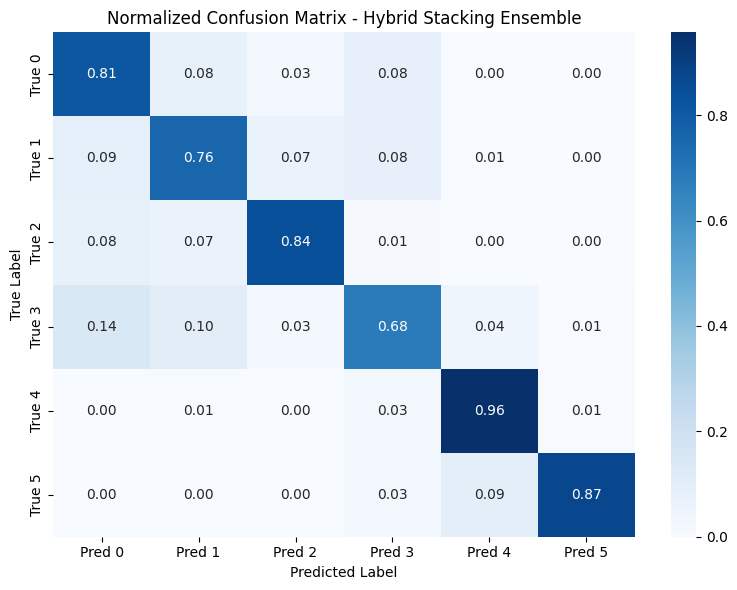

In [19]:
# ============================================================
# FINAL RESULTS
# ============================================================
print("\n" + "=" * 70)
print("FINAL RESULTS - HYBRID STACKING v5")
print("=" * 70)

# Classification report
print(f"\nTest Accuracy: {ens_acc:.4f}")
print(f"Quadratic Weighted Kappa (QWK): {ens_qwk:.4f}")
print(f"Top-2 Accuracy: {ens_top2:.4f}")
print(f"\nClassification Report:")
print(classification_report(meta_test_labels, ensemble_preds, digits=4))

# Confusion matrix
cm = confusion_matrix(meta_test_labels, ensemble_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=[f"Pred {i}" for i in range(NUM_CLASSES)],
            yticklabels=[f"True {i}" for i in range(NUM_CLASSES)])
plt.title("Normalized Confusion Matrix - Hybrid Stacking Ensemble")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cm_ensemble_final.png"), dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ============================================================
# COMPARISON TABLE: Base models vs Meta-learners vs Ensemble
# ============================================================

rows = []

# Base models
for k, r in base_results.items():
    rows.append({
        'Model': f"Base: {k}",
        'Accuracy': r['test_acc'],
        'QWK': r['qwk'],
        'Top-2 Acc': r['top2_acc'],
        'Time (min)': r['training_time']
    })

# Meta-learners
for name, res in meta_results.items():
    rows.append({
        'Model': f"Meta: {name}",
        'Accuracy': res['acc'],
        'QWK': res['qwk'],
        'Top-2 Acc': res['top2'],
        'Time (min)': '-'
    })

# Final ensemble
rows.append({
    'Model': 'ENSEMBLE (final)',
    'Accuracy': ens_acc,
    'QWK': ens_qwk,
    'Top-2 Acc': ens_top2,
    'Time (min)': '-'
})

comparison_df = pd.DataFrame(rows)
print("\n" + comparison_df.to_string(index=False))

comparison_df.to_csv(os.path.join(OUTPUT_DIR, "full_comparison.csv"), index=False)
print(f"\nComparison saved to {OUTPUT_DIR}/full_comparison.csv")


           Model  Accuracy      QWK  Top-2 Acc Time (min)
 Base: camelbert  0.801313 0.886638   0.933771  39.571651
   Base: arabert  0.791407 0.870047   0.920971  49.448005
   Base: marbert  0.803540 0.882176   0.933549  49.217235
   Meta: xgboost  0.821349 0.889340   0.947907          -
    Meta: logreg  0.775935 0.854396   0.906167          -
       Meta: mlp  0.776825 0.865078   0.897596          -
ENSEMBLE (final)  0.821126 0.889456   0.948798          -

Comparison saved to ./hybrid_stacking_v5/full_comparison.csv


In [21]:
# ============================================================
# SAVE EVERYTHING
# ============================================================

# Save meta-learner artifacts
joblib.dump({
    'meta_scaler': meta_scaler_X,
    'best_meta_name': best_meta_name,
    'meta_results': {k: {kk: vv for kk, vv in v.items() if kk != 'model'}
                     for k, v in meta_results.items()},
    'ensemble_qwk': ens_qwk,
    'ensemble_acc': ens_acc,
    'base_model_names': BASE_MODELS,
}, os.path.join(OUTPUT_DIR, "meta_learner_artifacts.joblib"))

# Save the best single meta-learner model
if best_meta_name == 'xgboost':
    joblib.dump(meta_results['xgboost']['model'],
                os.path.join(OUTPUT_DIR, "best_meta_xgboost.joblib"))
elif best_meta_name == 'logreg':
    joblib.dump(meta_results['logreg']['model'],
                os.path.join(OUTPUT_DIR, "best_meta_logreg.joblib"))

print(f"All artifacts saved to {OUTPUT_DIR}/")
print("\nDone.")

All artifacts saved to ./hybrid_stacking_v5/

Done.
